# XOR, Separabilidad Lineal y Por Qué Importa la No-Linealidad

Este notebook conecta algunas ideas que aparecen temprano en el Deep Learning:

- **XOR** como el ejemplo más pequeño de una *interacción de características*
- Qué significa **linealmente separable** en la práctica
- Cómo se relacionan el **Perceptron**, la **regresión lineal** y la **regresión logística**
- Por qué las **Activation Functions** (no-linealidad) son el ingrediente clave del Deep Learning

Usamos matemática mínima y nos apoyamos en gráficas y código.

**Prerrequisitos:** [01_intro_neural_networks.ipynb](../01_intro_neural_networks.ipynb), [02_pytorch_basics.ipynb](../02_pytorch_basics.ipynb)

## La idea del XOR

XOR significa: **o** la condición A **o** la condición B es verdadera, **pero no ambas**.

| x₁ | x₂ | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

¿Por qué nos importa? Porque XOR es el ejemplo más pequeño que requiere **combinar condiciones** — el tipo de lógica que aparece en proyectos reales como interacciones de características.

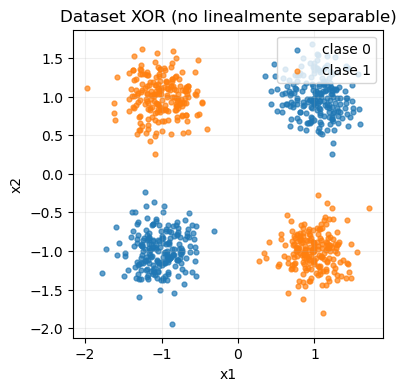

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_noisy_xor(n_per_corner: int = 200, noise: float = 0.25, seed: int = 0):
    rng = np.random.default_rng(seed)
    corners = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=np.float32)
    X = np.repeat(corners, repeats=n_per_corner, axis=0)
    X = X + rng.normal(0.0, noise, size=X.shape).astype(np.float32)
    y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(np.float32)
    return X, y

X, y = make_noisy_xor()

plt.figure(figsize=(4, 4))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=12, alpha=0.7, label="clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=12, alpha=0.7, label="clase 1")
plt.title("Dataset XOR (no linealmente separable)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.2)
plt.legend(loc="upper right")
plt.show()

## ¿Qué significa "linealmente separable"?

Un modelo es **lineal** (para clasificación) si solo puede separar clases usando **una frontera recta**:

- Una **línea** en 2D
- Un **plano** en 3D
- Un **hiperplano** en dimensiones superiores

Si los datos no pueden dividirse con una sola frontera recta, entonces **ningún entrenamiento** logrará que un modelo puramente lineal lo resuelva — es una limitación de *representación*, no de optimización.

## Perceptron, regresión lineal, regresión logística

Los tres parten del mismo cómputo central — una **puntuación lineal**:

$$\text{puntuación} = w_1 x_1 + w_2 x_2 + \ldots + b$$

Difieren en lo que ocurre *después* y qué Loss optimizan:

| Modelo | Después de la puntuación lineal | Loss | Para qué sirve |
|--------|--------------------------------|------|----------------|
| **Regresión lineal** | Nada (número bruto) | MSE | Regresión |
| **Perceptron (clásico)** | Umbral duro (función escalón) | Pérdida del Perceptron | Clasificación binaria (histórico) |
| **Regresión logística** | Umbral suave (sigmoid) | BCE | Clasificación binaria (baseline moderno) |

En PyTorch, un solo `nn.Linear(2, 1)` + sigmoid + Loss BCE **es** regresión logística.

## Demo: los modelos lineales fallan en XOR

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(0)

X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y).reshape(-1, 1)

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = (torch.sigmoid(logits) > 0.5).to(dtype=y_true.dtype)
    return float((preds == y_true).to(torch.float32).mean().item())

def plot_probability_surface(ax, model: nn.Module, title: str):
    xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 250), np.linspace(-2.5, 2.5, 250))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).reshape(xx.shape).cpu().numpy()
    ax.contourf(xx, yy, probs, levels=25, alpha=0.65)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.2)

def scatter_data(ax):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=10, alpha=0.7, label="clase 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10, alpha=0.7, label="clase 1")
    ax.legend(loc="upper right")

In [ ]:
# 1) Regresión lineal forzada a clasificación (MSE + umbral)
linreg = nn.Linear(2, 1)
opt = torch.optim.SGD(linreg.parameters(), lr=0.1)
for _ in range(400):
    opt.zero_grad()
    loss = nn.MSELoss()(linreg(X_t), y_t)
    loss.backward()
    opt.step()

# 2) Regresión logística (BCEWithLogitsLoss)
logreg = nn.Linear(2, 1)
opt = torch.optim.SGD(logreg.parameters(), lr=0.5)
for _ in range(400):
    opt.zero_grad()
    loss = nn.BCEWithLogitsLoss()(logreg(X_t), y_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    print(f"Precisión de regresión lineal: {accuracy_from_logits(linreg(X_t), y_t):.3f}")
    print(f"Precisión de regresión logística: {accuracy_from_logits(logreg(X_t), y_t):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_probability_surface(axes[0], linreg, "Regresión lineal (sigue siendo lineal)")
scatter_data(axes[0])
plot_probability_surface(axes[1], logreg, "Regresión logística (sigue siendo lineal)")
scatter_data(axes[1])
plt.tight_layout()
plt.show()

Ambos modelos siguen siendo **lineales en las entradas**, por lo que comparten la misma limitación fundamental en XOR. La regresión logística es una mejor herramienta de clasificación, pero sigue siendo un clasificador lineal.

## Ingeniería de características vs. aprendizaje de representaciones

Una forma de resolver XOR con un modelo lineal es **añadir manualmente una característica de interacción**.

Si añades `x₃ = x₁ × x₂`, las clases se vuelven fáciles de separar con una frontera recta en el espacio 3D expandido.

Esta es una conexión clave:
- **ML clásico**: se construyen características de interacción a mano (características polinómicas, conocimiento del dominio).
- **Deep Learning**: se deja que la red **aprenda** interacciones útiles automáticamente mediante Hidden Layers + Activations.

In [ ]:
# Añadir una característica de interacción: x3 = x1 * x2
X3 = (X[:, 0] * X[:, 1]).reshape(-1, 1).astype(np.float32)
X_fe_t = torch.from_numpy(np.concatenate([X.astype(np.float32), X3], axis=1))

logreg_fe = nn.Linear(3, 1)
opt = torch.optim.SGD(logreg_fe.parameters(), lr=0.5)
for _ in range(400):
    opt.zero_grad()
    loss = nn.BCEWithLogitsLoss()(logreg_fe(X_fe_t), y_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    print(f"Precisión de regresión logística + característica x1*x2: {accuracy_from_logits(logreg_fe(X_fe_t), y_t):.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 250), np.linspace(-2.5, 2.5, 250))
grid_xy = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_x3 = (grid_xy[:, 0] * grid_xy[:, 1]).reshape(-1, 1)
grid_fe = torch.from_numpy(np.concatenate([grid_xy, grid_x3], axis=1))
with torch.no_grad():
    probs = torch.sigmoid(logreg_fe(grid_fe)).reshape(xx.shape).cpu().numpy()
ax.contourf(xx, yy, probs, levels=25, alpha=0.65)
scatter_data(ax)
ax.set_title("Regresión logística con característica x1*x2")
plt.tight_layout()
plt.show()

## Por qué las Activations son el ingrediente clave

Un malentendido común: "si una Layer lineal no es suficiente, apilemos dos."

Pero **lineal → lineal sigue siendo lineal** — la composición colapsa en una única transformación lineal. Apilar Layers solo se vuelve interesante cuando se insertan **Activations no lineales** (ReLU, tanh, …) entre ellas.

In [ ]:
# Prueba: dos Layers lineales apiladas = una Layer lineal
torch.manual_seed(0)
layer1 = nn.Linear(2, 4)
layer2 = nn.Linear(4, 1)

x = torch.randn(10, 2)
y_stacked = layer2(layer1(x))

# Layer lineal única equivalente
W_equiv = layer2.weight @ layer1.weight
b_equiv = layer2.bias + (layer2.weight @ layer1.bias)
y_equiv = x @ W_equiv.T + b_equiv

print(f"Diferencia máxima: {(y_stacked - y_equiv).abs().max().item():.6g}")

## No-linealidad: un pequeño MLP resuelve XOR

En lugar de añadir `x₁ × x₂` manualmente, usamos una red pequeña con una Activation Function. La Hidden Layer **aprende** "detectores" intermedios que se comportan como características construidas — pero aprendidas a partir de los datos.

In [ ]:
mlp = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
opt = torch.optim.Adam(mlp.parameters(), lr=0.05)
bce = nn.BCEWithLogitsLoss()

for _ in range(600):
    opt.zero_grad()
    loss = bce(mlp(X_t), y_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    print(f"Precisión del MLP: {accuracy_from_logits(mlp(X_t), y_t):.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
plot_probability_surface(ax, mlp, "Superficie de probabilidad del MLP (no lineal)")
scatter_data(ax)
plt.tight_layout()
plt.show()

## Teorema de Aproximación Universal

> Una red feedforward con una sola Hidden Layer que contiene **suficientes** neuronas puede aproximar cualquier función continua en un subconjunto compacto de ℝⁿ.

**Implicaciones:**
- Los MLPs son teóricamente lo suficientemente poderosos para cualquier tarea.
- "Suficientes" neuronas puede ser imprácticamente grande.
- Las redes más profundas suelen funcionar mejor que las más anchas en la práctica.
- Encontrar los Weights correctos es la parte difícil (el entrenamiento).

## Experimento con el tamaño de la Hidden Layer

In [ ]:
hidden_sizes = [2, 4, 8, 16, 32]
results = {}

for h in hidden_sizes:
    mlp = nn.Sequential(nn.Linear(2, h), nn.ReLU(), nn.Linear(h, 1))
    opt = torch.optim.Adam(mlp.parameters(), lr=0.05)
    for _ in range(600):
        opt.zero_grad()
        bce(mlp(X_t), y_t).backward()
        opt.step()
    with torch.no_grad():
        results[h] = accuracy_from_logits(mlp(X_t), y_t)
    print(f"Tamaño Hidden {h:2d}: {results[h]:.3f}")

Incluso 2 neuronas ocultas pueden representar XOR (coincidiendo con los 2 "detectores" que necesitamos), pero más neuronas hacen el entrenamiento más robusto — el Optimizer tiene más caminos hacia una solución.

## Qué llevarte de aquí

- XOR es un *dataset de juguete*, pero la idea que representa (**interacciones de características**) está en todas partes.
- La regresión lineal / la regresión logística / el Perceptron comparten el mismo núcleo de *puntuación lineal*.
- Para manejar problemas no lineales, necesitas:
  - **Ingeniería de características** (añadir características de interacción manualmente), o
  - **Modelos no lineales** (Hidden Layers + Activation Functions).
- Esta es la razón real por la que las Activations importan: permiten que los modelos construyan representaciones ricas en lugar de quedarse atascados con fronteras rectas.
- El **Teorema de Aproximación Universal** garantiza que una sola Hidden Layer *puede* representar cualquier función — pero las redes más profundas suelen ser más prácticas.